In [ ]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from joblib import dump
from h5py import File

import csiborgtools

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [20]:
profile = "gauss"

rvoid, rLG, vrad = csiborgtools.flow.load_void_size_variation("gauss", "vrad", which_run="all")

2025-02-17 15:34:42   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/processed_gauss_vrad.hdf5`.


In [27]:
vrad_chosen.shape

(181, 401)

In [31]:
!rm /mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/void_*

mean_mag = 10.31
std_mag = 0.83
a_TF = -23.2
b_TF = -3
beta = 1.0

kmax = 1
seed = 42

rvoid_chosen = 1.0  # Fractional void size
rLG_chosen = 20.0   # Mpc

i = np.abs(rvoid - rvoid_chosen).argmin()
j = np.abs(rLG - rLG_chosen).argmin()
vrad_chosen = vrad[i, j]

# rvoid needs to be converted to percentage
h_void = csiborgtools.flow.select_void_h(100 * rvoid_chosen, "gauss", )
print(f"h_void = {h_void}")

for k in trange(kmax):
    mock, truths = csiborgtools.flow.mock_void(
        vrad_chosen, h_void,
        mean_mag=mean_mag, std_mag=std_mag,
        a_TF=a_TF, b_TF=b_TF, sigma_TF=0.2,
        sigma_cal=0.05, sigma_v=250,
        beta=beta, seed=seed, verbose=True,)
    seed += 1

    fname = f"/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/void_mock_seed{k}.hdf5"  # noqa
    print("Saving to ", fname)
    with File(fname, 'w') as f:
        for key in mock.keys():
            f.create_dataset(key, data=mock[key])

    fname_truths = fname.replace(".hdf5", "_truths.pkl")
    dump(truths, fname_truths)

rm: cannot remove '/mnt/extraspace/rstiskalek/csiborg_postprocessing/flow_mock/void_*': No such file or directory
h_void = 0.7732155199999999


  0%|          | 0/1 [00:00<?, ?it/s]

phi_grid =  [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180]
phi.min(), phi.max()  0.9335563602866538 177.9831839381938
r.min() , r.max() =  10.949823963638188 220.94129473620083
r_grid.min(), r_grid.max() =  0.0 309.286208
Assuming grid of 181 points in phi and 401 points in r.


  0%|          | 0/1 [00:00<?, ?it/s]

r.max() =  220.94129473620083


ValueError: Some void velocities are outside the interpolation range.

In [24]:
len(mock["r"])

2000

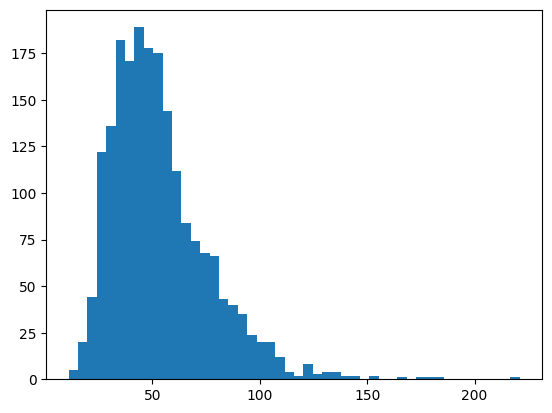

In [25]:
plt.figure()
plt.hist(mock["r"], bins="auto")

plt.show()